
# TRNG Project



## background
We read some articles and start with several main ideas, here a brief explanation-
1. The first one is to use the diffrent oscilator jitters for entropy source. we took one fast oscilator (32Mhz) for a COUNTER peripheral that inside the XMEGA mcu and we talk anouther independent oscillator that runs for RTC (real time counter). We use the jitter and the noise f this oscillators as an entropy source, After each OVF of the RTC we took the COUNTER value (the 8 lsb bits).

2. we took the ADC peripheral of the mcu and want to use some analog entropy (sensors) and digitized them to get random bits. we try two sources that we have inside the MCU - VCC/10, TEMP SENSOR. we see that in room conditions the temp gives us ~ 5 bits if entopy for sample, and vcc/10 ~ 3 bits per sample, we take it as an start point and trying to achive the best results. 

## 1) Build firmware

In [519]:
import chipwhisperer as cw
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange

scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial2)
scope.default_setup()

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 15561173                  to 39854105                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 29538459                 
scope.clock.adc_rate                     changed from 0.0                       to 29538459.0               
scope.clock.clkgen_

In [530]:
%%bash
make -C ../src/ PLATFORM=CWLITEXMEGA SS_VER=SS_VER_2_1

make: Entering directory '/mnt/c/Users/alona/ChipWhisperer/chipwhisperer/secure-hardware/TRNG/combined_trng/src'
No CRYPTO_TARGET passed - defaulting to TINYAES128C
Building for platform CWLITEXMEGA with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
avr-gcc (GCC) 7.3.0
Copyright (C) 2017 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWLITEXMEGA 
.
Compiling:
-en     adc_utils.c ...
-e Done!
.
Compiling:
-en     init.c ...
-e Done!
.
Compiling:
-en     main.c ...
-e Done!
.
Compiling:
-en     reset.c ...
-e Done!
.
Compiling:
-en     rng.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/hal/hal.c ...
-e Done!
.


## 2) Program target (XMEGA on CW303)

In [531]:
hex = "../src/build/combined_trng-CWLITEXMEGA.hex"
cw.program_target(scope, cw.programmers.XMEGAProgrammer, hex)

XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 4577 bytes


## 3) Basic check

why the first always falls???????

### restart callback check

In [532]:
import time

target.flush()

# Send reset command
target.simpleserial_write('x', b'')
# Give MCU time to reboot
time.sleep(0.1)
resp = target.read()
if "##BOOT##" in resp:
    print("MCU rebooted OK:", resp)
else:
    print("No BOOT marker seen, got:", resp)




MCU rebooted OK: ÿ##BOOT##× 


### TRNG callback check

In [527]:
# Ask target for that chunk
scmd = 2
want = 10
target.send_cmd('b',scmd,want.to_bytes(1,'little'))

# Read exactly 'want' bytes (no ack check until final)
chunk = target.simpleserial_read('r', want, timeout=2000)
if chunk is None or len(chunk) != want:
    print("Bad block, skipping…")

print("Received", len(chunk), "bytes:", chunk.hex())

Received 10 bytes: 6608b3de03a2212e0e7c


# Collect data & statics

Need 1250 more bytes…
Need 1240 more bytes…
Need 1230 more bytes…
Need 1220 more bytes…
Need 1210 more bytes…
Need 1200 more bytes…
Need 1190 more bytes…
Need 1180 more bytes…
Need 1170 more bytes…
Need 1160 more bytes…
Need 1150 more bytes…
Need 1140 more bytes…
Need 1130 more bytes…
Need 1120 more bytes…
Need 1110 more bytes…
Need 1100 more bytes…
Need 1090 more bytes…
Need 1080 more bytes…
Need 1070 more bytes…
Need 1060 more bytes…
Need 1050 more bytes…
Need 1040 more bytes…
Need 1030 more bytes…
Need 1020 more bytes…
Need 1010 more bytes…
Need 1000 more bytes…
Need 990 more bytes…
Need 980 more bytes…
Need 970 more bytes…
Need 960 more bytes…
Need 950 more bytes…
Need 940 more bytes…
Need 930 more bytes…
Need 920 more bytes…
Need 910 more bytes…
Need 900 more bytes…
Need 890 more bytes…
Need 880 more bytes…
Need 870 more bytes…
Need 860 more bytes…
Need 850 more bytes…
Need 840 more bytes…
Need 830 more bytes…
Need 820 more bytes…
Need 810 more bytes…
Need 800 more bytes…
Need 790

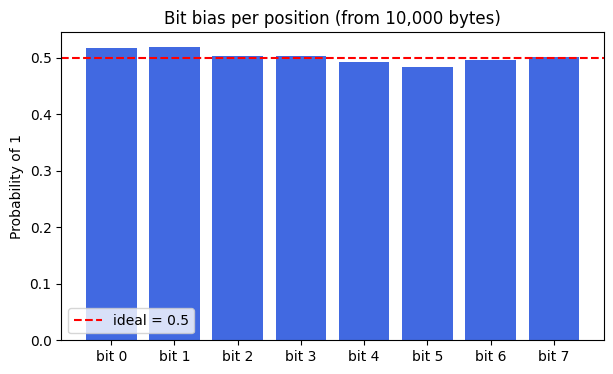


Byte distribution stats:
Min prob: 0.0008, Max prob: 0.0136, Expected = 0.0039


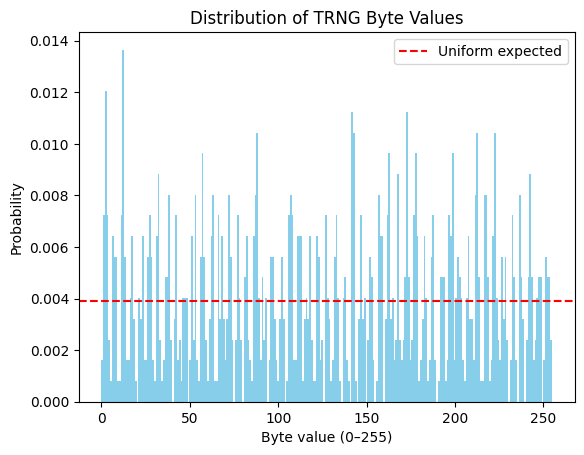

In [ ]:
import numpy as np
import time
import logging   # <-- add this

# Silence ChipWhisperer "Target" warnings
logging.getLogger("ChipWhisperer Target").setLevel(logging.ERROR)

name_str = f"1m_bit_random_data_osc_in_firmware_30k_sequential"

CHUNK = 10            # safe per-request size
I = 125*3
N = I*CHUNK               # total bytes you want
buf = bytearray()
scmd = 0
# Loop until we have N bytes
remaining = N
while remaining > 0:
    print(f"Need {remaining} more bytes…")
    target.flush()
    want = min(CHUNK, remaining)


    # Ask target for that chunk
    target.send_cmd('b',scmd,want.to_bytes(1,'little'))

    # Read exactly 'want' bytes (no ack check until final)
    chunk = target.simpleserial_read('r', want, timeout=200000)
    if chunk is None or len(chunk) != want:
        print("Bad block, skipping…")
        continue

    buf.extend(chunk)
    remaining -= want


# ---------- Analysis ----------
data = np.frombuffer(buf, dtype=np.uint8)
biases = []

for b in range(8):
    ones = np.count_nonzero((data >> b) & 1)
    p1 = ones / len(data)
    biases.append(p1)
    print(f"bit {b}: p1={p1:.5f}")

# ---------- Plot ----------
plt.figure(figsize=(7,4))
plt.bar(range(8), biases, color="royalblue")
plt.axhline(0.5, color="red", linestyle="--", label="ideal = 0.5")
plt.xticks(range(8), [f"bit {i}" for i in range(8)])
plt.ylabel("Probability of 1")
plt.title("Bit bias per position (from 10,000 bytes)")
plt.legend()
plt.show()


# ===== 3. Byte value distribution =====
values, counts = np.unique(data, return_counts=True)
probs = counts / len(data)

print("\nByte distribution stats:")
print(f"Min prob: {probs.min():.4f}, Max prob: {probs.max():.4f}, Expected = {1/256:.4f}")

plt.hist(data, bins=256, range=(0, 255), density=True, color='skyblue')
plt.axhline(1/256, color='r', linestyle='--', label="Uniform expected")
plt.xlabel("Byte value (0–255)")
plt.ylabel("Probability")
plt.title("Distribution of TRNG Byte Values")
plt.legend()
plt.show()

np.save("../data/sequential/"+name_str, data)
# --- Sequential test: write one long file ---
bits_seq = np.unpackbits(data)
# Pack bits into bytes
packed = np.packbits(bits_seq)
packed.tofile("C:\\Users\\alona\\ChipWhisperer\\chipwhisperer\\secure-hardware\\TRNG\\sts-2.1.2\\data\\sequential\\"+name_str+".bin")



## sequential data

Need 10000000 more bytes…
Need 9999900 more bytes…
Need 9999800 more bytes…
Need 9999700 more bytes…
Need 9999600 more bytes…
Need 9999500 more bytes…
Need 9999400 more bytes…
Need 9999300 more bytes…
Need 9999200 more bytes…
Need 9999100 more bytes…
Need 9999000 more bytes…
Need 9998900 more bytes…
Need 9998800 more bytes…
Need 9998700 more bytes…
Need 9998600 more bytes…
Need 9998500 more bytes…
Need 9998400 more bytes…
Need 9998300 more bytes…
Need 9998200 more bytes…
Need 9998100 more bytes…
Need 9998000 more bytes…
Need 9997900 more bytes…
Need 9997800 more bytes…
Need 9997700 more bytes…
Need 9997600 more bytes…
Need 9997500 more bytes…
Need 9997400 more bytes…
Need 9997300 more bytes…
Need 9997200 more bytes…
Need 9997100 more bytes…
Need 9997000 more bytes…
Need 9996900 more bytes…
Need 9996800 more bytes…
Need 9996700 more bytes…
Need 9996600 more bytes…
Need 9996500 more bytes…
Need 9996400 more bytes…
Need 9996300 more bytes…
Need 9996200 more bytes…
Need 9996100 more bytes…

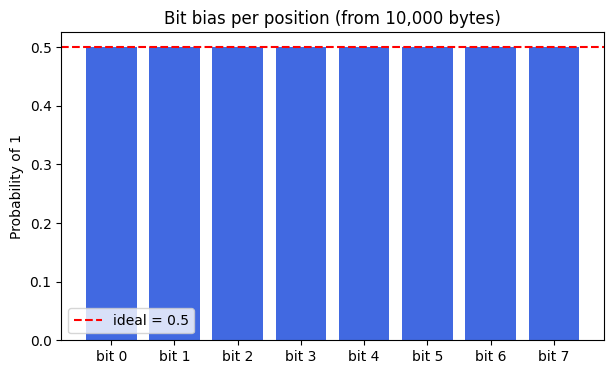


Byte distribution stats:
Min prob: 0.0038, Max prob: 0.0039, Expected = 0.0039


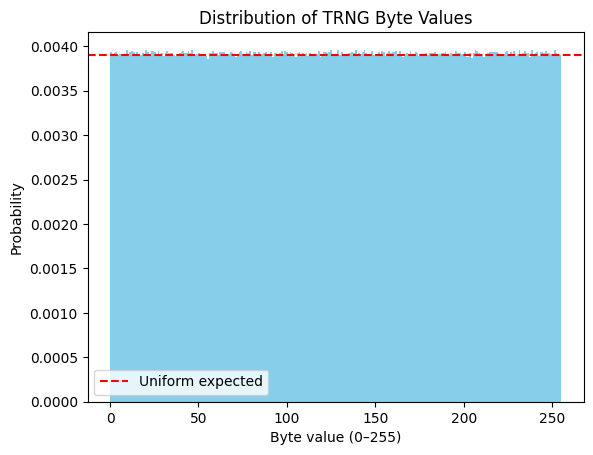

In [540]:
import numpy as np
import time
import logging   # <-- add this

# Silence ChipWhisperer "Target" warnings
logging.getLogger("ChipWhisperer Target").setLevel(logging.ERROR)

name_str = f"1m_bit_random_data_crc_in_firmware_1byte_80M_sequential"

CHUNK = 100            # safe per-request size
I = 1250*80
N = I*CHUNK               # total bytes you want
buf = bytearray()
scmd = 2
# Loop until we have N bytes
remaining = N
while remaining > 0:
    print(f"Need {remaining} more bytes…")
    target.flush()
    want = min(CHUNK, remaining)


    # Ask target for that chunk
    target.send_cmd('b',scmd,want.to_bytes(1,'little'))

    # Read exactly 'want' bytes (no ack check until final)
    chunk = target.simpleserial_read('r', want, timeout=200000)
    if chunk is None or len(chunk) != want:
        print("Bad block, skipping…")
        continue

    buf.extend(chunk)
    remaining -= want


# ---------- Analysis ----------
data = np.frombuffer(buf, dtype=np.uint8)
biases = []

for b in range(8):
    ones = np.count_nonzero((data >> b) & 1)
    p1 = ones / len(data)
    biases.append(p1)
    print(f"bit {b}: p1={p1:.5f}")

# ---------- Plot ----------
plt.figure(figsize=(7,4))
plt.bar(range(8), biases, color="royalblue")
plt.axhline(0.5, color="red", linestyle="--", label="ideal = 0.5")
plt.xticks(range(8), [f"bit {i}" for i in range(8)])
plt.ylabel("Probability of 1")
plt.title("Bit bias per position (from 10,000 bytes)")
plt.legend()
plt.show()


# ===== 3. Byte value distribution =====
values, counts = np.unique(data, return_counts=True)
probs = counts / len(data)

print("\nByte distribution stats:")
print(f"Min prob: {probs.min():.4f}, Max prob: {probs.max():.4f}, Expected = {1/256:.4f}")

plt.hist(data, bins=256, range=(0, 255), density=True, color='skyblue')
plt.axhline(1/256, color='r', linestyle='--', label="Uniform expected")
plt.xlabel("Byte value (0–255)")
plt.ylabel("Probability")
plt.title("Distribution of TRNG Byte Values")
plt.legend()
plt.show()

np.save("../data/sequential/"+name_str, data)
# --- Sequential test: write one long file ---
bits_seq = np.unpackbits(data)
# Pack bits into bytes
packed = np.packbits(bits_seq)
packed.tofile("C:\\Users\\alona\\ChipWhisperer\\chipwhisperer\\secure-hardware\\TRNG\\sts-2.1.2\\data\\sequential\\"+name_str+".bin")



In [541]:
from scipy.stats import entropy,beta

H = entropy(probs, base=2)
print(f"Shannon entropy: {H:.4f} bits per byte (ideal = 8)")

p_max = probs.max()
Hmin_byte = -np.log2(p_max)
print(f"Min-entropy (per byte): {Hmin_byte:.4f} bits; p_max={p_max:.6f}")


# Optional: 99% lower bound using counts
N = counts.sum()            # total samples
c_max = counts.max()        # count of most common byte
alpha = 0.01                # 99% confidence
pmax_upper = beta.ppf(1 - alpha, c_max + 1, N - c_max)  # upper bound on p_max
Hmin_lb_byte = -np.log2(pmax_upper)
print(f"99% lower bound H_min (per byte): {Hmin_lb_byte:.4f} bits")

Shannon entropy: 8.0000 bits per byte (ideal = 8)
Min-entropy (per byte): 7.9851 bits; p_max=0.003947
99% lower bound H_min (per byte): 7.9683 bits


In [542]:
from scipy.stats import chisquare

# Build observed histogram (256 bins, one per possible byte value)
observed, _ = np.histogram(data, bins=256, range=(0, 256))

# Expected: uniform distribution with same total count
expected = np.full(256, len(data) / 256)

# Chi-square test
chi2, pval = chisquare(observed, expected)
print(f"Chi-square = {chi2:.2f}, p = {pval:.3e}")



Chi-square = 229.23, p = 8.753e-01


Autocorrelation lag 1: 0.000045
Autocorrelation lag 2: 0.000172
Autocorrelation lag 3: -0.000005
Autocorrelation lag 4: -0.000105
Autocorrelation lag 5: -0.000086
Autocorrelation lag 6: -0.000098
Autocorrelation lag 7: 0.000073
Autocorrelation lag 8: -0.000251
Autocorrelation lag 12: 0.000011
Autocorrelation lag 16: 0.000190
Autocorrelation lag 32: -0.000183
Autocorrelation lag 64: -0.000111


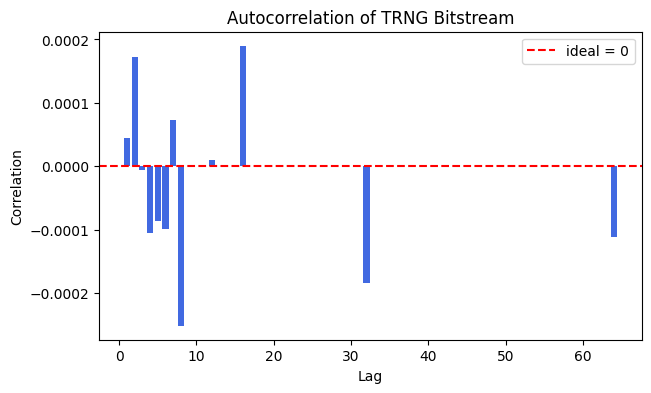

In [543]:
import numpy as np
import matplotlib.pyplot as plt

# Convert bytes → bits (flatten into 0/1 array)
bits = np.unpackbits(data).astype(float)

def autocorr(bits, lag):
    """Compute autocorrelation at a given lag safely."""
    if lag >= len(bits):
        return np.nan
    return np.corrcoef(bits[:-lag], bits[lag:])[0, 1]

# Choose lags to test
lags = [1, 2, 3,4,5,6,7, 8, 12, 16, 32, 64]
results = {}

for lag in lags:
    ac = autocorr(bits, lag)
    results[lag] = ac
    print(f"Autocorrelation lag {lag}: {ac:.6f}")

# --- Plot autocorrelation results ---
plt.figure(figsize=(7,4))
plt.bar(results.keys(), results.values(), color="royalblue")
plt.axhline(0, color="red", linestyle="--", label="ideal = 0")
plt.ylabel("Correlation")
plt.xlabel("Lag")
plt.title("Autocorrelation of TRNG Bitstream")
plt.legend()
plt.show()


In [544]:
import numpy as np
from scipy.stats import chisquare

def poker_test(bits, m_values=[2,3,4,5,6,8]):
    N = len(bits)
    results = []
    for m in m_values:
        num_chunks = N // m
        if num_chunks < 50:
            continue  # not enough samples for this m

        # group into m-bit chunks
        chunks = np.packbits(bits[:num_chunks*m].reshape(-1, m), axis=-1, bitorder='little').flatten()
        freqs = np.bincount(chunks, minlength=2**m)

        # expected counts (uniform)
        expected = np.full(2**m, num_chunks / (2**m))
        chi2, pval = chisquare(freqs, expected)

        results.append((m, chi2, pval))

    return results



bits = np.unpackbits(data)  # turn your bytes into bitstream
results = poker_test(bits)

for m, chi2, pval in results:
    print(f"m={m}: Chi²={chi2:.2f}, p={pval:.3f}")



m=2: Chi²=2.06, p=0.560
m=3: Chi²=4.18, p=0.759
m=4: Chi²=16.01, p=0.382
m=5: Chi²=22.00, p=0.883
m=6: Chi²=59.65, p=0.596
m=8: Chi²=229.23, p=0.875


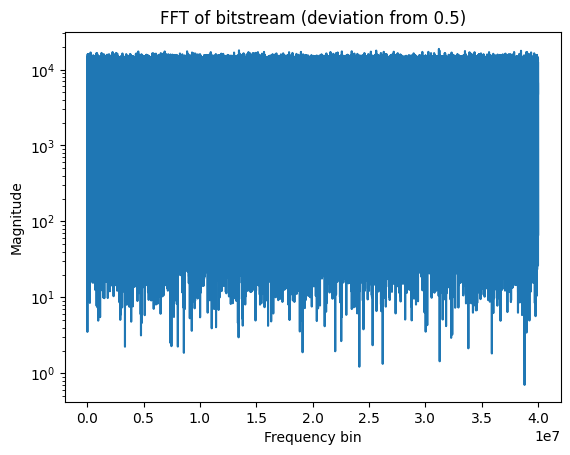

In [545]:
import matplotlib.pyplot as plt

fft_vals = np.fft.fft(bits - 0.5)
plt.semilogy(np.abs(fft_vals[:len(fft_vals)//2]))
plt.title("FFT of bitstream (deviation from 0.5)")
plt.xlabel("Frequency bin")
plt.ylabel("Magnitude")
plt.show()


## restart set

In [539]:
import numpy as np
import logging
import time

# Silence ChipWhisperer "Target" warnings
logging.getLogger("ChipWhisperer Target").setLevel(logging.ERROR)

# Parameters
NUM_TESTS = 600       # how many restart runs
BYTES_PER_SAMPLE = 6250 # 1000 bits minimum
CHUNK = 100            # safe per-request size
scmd = 2
name_str = "restart_test_samples_CRC_1byte_50K_per_reset_last_600k"
all_samples = []

for i in range(NUM_TESTS):
    print(f"[{i+1}/{NUM_TESTS}] collecting...")

    # Periodic reset
    print(">>> Resetting target...")
    target.simpleserial_write('x', b'')   # send reset command
    time.sleep(0.1)                       # give MCU time to reboot
    boot = target.read()
    print("Boot marker:", boot)
 
    buf = bytearray()
    remaining = BYTES_PER_SAMPLE

    while remaining > 0:
        target.flush()   # reset UART buffers
        want = min(CHUNK, remaining)

        # Ask target for that chunk
        target.send_cmd('b', scmd, want.to_bytes(1, 'little'))

        chunk = target.simpleserial_read('r', want, timeout=2000)
        if chunk is None or len(chunk) != want:
            print("Bad block, skipping this sample...")
            continue

        buf.extend(chunk)
        remaining -= want

    # Store if successful
    if buf:
        all_samples.append(np.frombuffer(buf, dtype=np.uint8))

# Save all samples into one .npy file
all_samples = np.array(all_samples, dtype=np.uint8)

np.save("../data/restart/"+name_str, all_samples)
# --- Sequential test: write one long file ---
bits_seq = np.unpackbits(all_samples)
# Pack bits into bytes
packed = np.packbits(bits_seq)
packed.tofile("C:\\Users\\alona\\ChipWhisperer\\chipwhisperer\\secure-hardware\\TRNG\\sts-2.1.2\\data\\restart\\"+name_str+".bin")


[1/600] collecting...
>>> Resetting target...
_/~]õOñÝ
gê~ vµÃ ½Ç«\µÞplHÿ~°ÙæÉPµ[×f@ ¾Ë{O§¸ó©qXèâ±ê#B¿¯H&@Ñug}þíÕXÐS% eë ÿ##BOOT##× 
[2/600] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[3/600] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[4/600] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[5/600] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[6/600] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[7/600] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[8/600] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[9/600] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[10/600] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[11/600] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[12/600] collecting...
>>> Resetting target...
Boot marker: ÿ##BOOT##× 
[13/600] collecting...
>>> Resetting targe

## 6) Cleanup / disconnect (optional)

In [245]:

try:
    target.dis()
except Exception:
    pass
try:
    scope.dis()
except Exception:
    pass
print("Disconnected.")


Disconnected.
